# GRAHSP vs JAXSEDFit: Chimera SED Comparison

This notebook combines the single-object JAXSEDFit flow from Notebook 11 with the original GRAHSP runner from Notebook 12. It fits the same Chimera object with both models, then plots the two SED decompositions side by side.


## Setup

Run this notebook from `jaxsedfit/notebooks`. The GRAHSP repository should be the parent checkout that contains both `jaxsedfit/` and `sampler/dualsampler.py`, and the DSPS SSP cache should exist at `jaxsedfit/tempdata.h5`.

GRAHSP is optional. Set `RUN_GRAHSP=True` in the run-configuration cell to launch the original GRAHSP nested sampler. With the default `RUN_GRAHSP=False`, the notebook runs the JAXSEDFit side and uses existing GRAHSP outputs only if they are already present on disk.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table


def find_jaxsedfit_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src" / "jaxsedfit").is_dir():
            return path
        if (path / "jaxsedfit" / "src" / "jaxsedfit").is_dir():
            return path / "jaxsedfit"
    raise RuntimeError("Could not find the jaxsedfit checkout from the current directory.")


def find_grahsp_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "jaxsedfit" / "src" / "jaxsedfit").is_dir() and (path / "sampler" / "dualsampler.py").is_file():
            return path
    return None


jaxsedfit_root = find_jaxsedfit_root()
repo_root = find_grahsp_repo_root()
src_root = jaxsedfit_root / "src"
cigale_root = repo_root / "cigale" if repo_root is not None else None
sampler_script = repo_root / "sampler" / "dualsampler.py" if repo_root is not None else None
dsps_ssp_fn = jaxsedfit_root / "tempdata.h5"

for path in (src_root, cigale_root):
    if path is not None and path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from jaxsedfit.benchmark import build_chimera_fit_config, load_chimera_benchmark_dataset, select_chimera_subset
from jaxsedfit.core import JAXSEDFit
from jaxsedfit.mplstyle import style_path
from jaxsedfit.plotting import _COMPONENT_STYLE, _median_site, _percentile_site, _to_display_flux_density

plt.style.use(style_path())

print("repo_root:", repo_root)
if repo_root is None:
    print("GRAHSP repository root was not found. This is OK unless RUN_GRAHSP=True.")
print("jaxsedfit_root:", jaxsedfit_root)
print("sampler:", sampler_script)
print("DSPS SSP:", dsps_ssp_fn)
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root: None
GRAHSP repository root was not found. This is OK unless RUN_GRAHSP=True.
jaxsedfit_root: /Users/colinburke/research/jaxsedfit
sampler: None
DSPS SSP: /Users/colinburke/research/jaxsedfit/tempdata.h5


## Pick A Chimera Object

Use the same default object as Notebook 11 so this comparison is directly tied to the current JAXSEDFit example. Change `target_object_id` to compare another row from the full Chimera benchmark.


In [16]:
dataset = load_chimera_benchmark_dataset(jaxsedfit_root)
subset = select_chimera_subset(dataset, jaxsedfit_root)

print(f"Loaded {len(dataset.rows)} full Chimera benchmark rows")
print(f"Loaded {len(subset)} deterministic tutorial subset rows")
print("Example object IDs:", [str(r["id"]) for r in subset[:5]])

target_object_id = "075217.84+193542.2_315709_0.0001"

row = next((r for r in dataset.rows if str(r["id"]) == target_object_id), None)
if row is None:
    raise ValueError(f"target_object_id={target_object_id!r} was not found in the Chimera benchmark")

truth_logm = float(row["log_stellar_mass_truth"])
base_output_dir = jaxsedfit_root / "notebook_outputs" / "13_grahsp_vs_jaxsedfit_chimera_sed" / str(row["id"])
grahsp_output_dir = base_output_dir / "grahsp"
jaxsedfit_output_dir = base_output_dir / "jaxsedfit"
grahsp_output_dir.mkdir(parents=True, exist_ok=True)
jaxsedfit_output_dir.mkdir(parents=True, exist_ok=True)

print("object_id:", row["id"])
print("COSMOS ID:", row["ID_COSMOS"])
print("redshift:", row["redshift"])
print("chimera_QSO_weight:", row["chimera_QSO_weight"])
print("truth log stellar mass:", truth_logm)
print("output_dir:", base_output_dir)

[benchmark] Loading Chimera photometry from /Users/colinburke/research/jaxsedfit/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /Users/colinburke/research/jaxsedfit/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /Users/colinburke/research/jaxsedfit/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 270 benchmark rows
Loaded 18168 full Chimera benchmark rows
Loaded 270 deterministic tutorial subset rows
Example object IDs: ['143816.78+191955.5_493880_0.03', '173203.08+611751.8_497237_0.03', '174112.44+535632.5_496869_0.3', '142016.02+142822.2_704594_0.03', '205707.66+752603.8_705742_0.01']
object_id: 075217.84+193542.2_315709_0.0001
COSMOS ID: 315709
redshift: 0.12319999933242798
chimera_QSO_weight: 0.0001
truth log stellar mass: 9.08123
output_dir: /Users/colinburke/research/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/075

## Run JAXSEDFit

This mirrors Notebook 11. The default uses nested sampling because that is the active fit path there; lower `JAXSEDFit_NS_LIVE_POINTS` and `JAXSEDFit_NS_MAX_SAMPLES` for a quicker smoke test, or raise them for production-quality comparison.


78.41269441780035
log10 agn_amp: 34.054200496816605
Photometry-seeded prior centers:
  log_stellar_mass: {'dist': 'student_t', 'df': 5.0, 'loc': 10.0, 'scale': 2.0}
  log_agn_amp: {'dist': 'Normal', 'loc': 74.41269441780035, 'scale': 3.0}
Host energy balance enabled: True
Fixed AGN type: 1


sample: 100%|██████████| 200/200 [01:01<00:00,  3.24it/s, 255 steps of size 4.46e-03. acc. prob=0.82]
/Users/colinburke/research/jaxsedfit/src/jaxsedfit/plotting.py:720: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


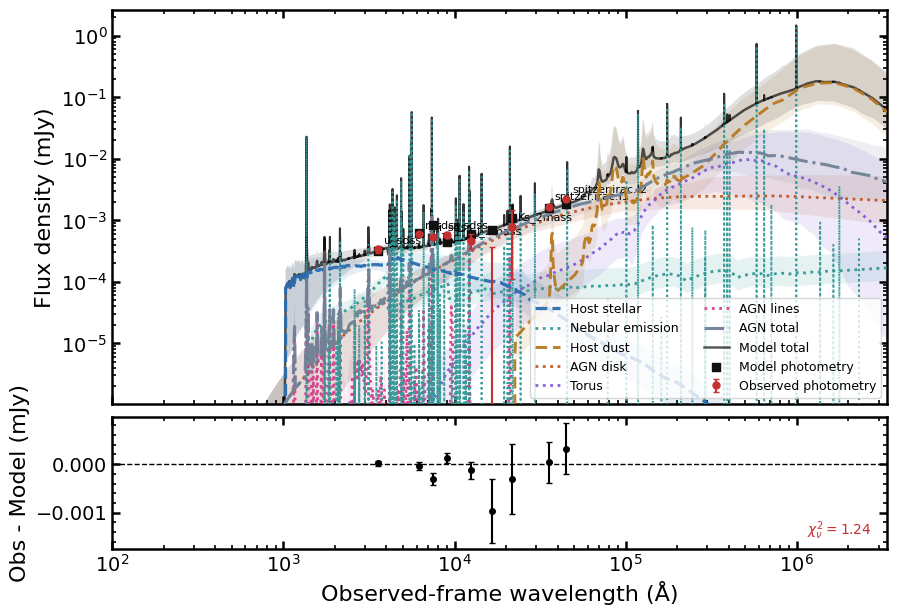

JAXSEDFit recovered log stellar mass: 5.878681662341199
JAXSEDFit 16-84% interval: (np.float64(5.6605467862895384), np.float64(6.210346357221353))
JAXSEDFit residual: -3.2025483376588006


In [ ]:
import numpyro.distributions as dist

RUN_JAXSEDFit = True

# GRAHSP is much slower than the JAXSEDFit example path. Leave this False
# for a JAXSEDFit-only run, or set it True to regenerate GRAHSP products.
RUN_GRAHSP = False
USE_EXISTING_GRAHSP_OUTPUTS = True
GRAHSP_NUM_LIVE_POINTS = 800
GRAHSP_NUM_POSTERIOR_SAMPLES = 3000
MAKE_GRAHSP_PLOTS = True

JAXSEDFit_FIT_METHOD = "optax+nuts"
JAXSEDFit_NS_LIVE_POINTS = 700
JAXSEDFit_NS_MAX_SAMPLES = 8000
JAXSEDFit_NS_DLOGZ = 10

cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
cfg.inference.map_steps = 2000
cfg.inference.learning_rate = 5e-3
cfg.inference.num_warmup = 100
cfg.inference.num_samples = 100
cfg.inference.method = JAXSEDFit_FIT_METHOD

from jaxsedfit.model import _estimate_log_agn_amp_prior_loc

fitter = JAXSEDFit(cfg)

current_photometry_seeded_loc = _estimate_log_agn_amp_prior_loc(
    fitter.context,
    cfg.observation.redshift,
)

print(current_photometry_seeded_loc)
print("log10 agn_amp:", current_photometry_seeded_loc / np.log(10))

cfg.prior_config.agn.log_amp = dist.Normal(
    loc=current_photometry_seeded_loc - 4.0,
    scale=3.0,
)

cfg.agn.fit_agn = False

print("Photometry-seeded prior centers:")
prior_mapping = cfg.prior_config.to_mapping()
print("  log_stellar_mass:", prior_mapping.get("log_stellar_mass"))
print("  log_agn_amp:", prior_mapping.get("log_agn_amp"))
print("Host energy balance enabled:", cfg.galaxy.use_energy_balance)
print("Fixed AGN type:", cfg.agn.agn_type)

if RUN_JAXSEDFit:
    jaxsedfit_fitter = JAXSEDFit(cfg)
    cfg.inference.ns_num_live_points = JAXSEDFit_NS_LIVE_POINTS
    cfg.inference.ns_max_samples = JAXSEDFit_NS_MAX_SAMPLES
    cfg.inference.ns_dlogz = JAXSEDFit_NS_DLOGZ
    cfg.output.plot_fig = True
    cfg.output.save_fig = False
    cfg.output.save_result = False
    jaxsedfit_fit_result = jaxsedfit_fitter.fit(progress_bar=True)
    jaxsedfit_pred = jaxsedfit_fitter.predict()
    jaxsedfit_samples = np.asarray(jaxsedfit_fitter.samples["log_stellar_mass"], dtype=float).reshape(-1)
    jaxsedfit_logm16, jaxsedfit_recovered_logm, jaxsedfit_logm84 = np.percentile(jaxsedfit_samples, [16.0, 50.0, 84.0])
    print("JAXSEDFit recovered log stellar mass:", jaxsedfit_recovered_logm)
    print("JAXSEDFit 16-84% interval:", (jaxsedfit_logm16, jaxsedfit_logm84))
    print("JAXSEDFit residual:", jaxsedfit_recovered_logm - truth_logm)
else:
    print("RUN_JAXSEDFit is False; set it to True to fit and generate the SED prediction.")


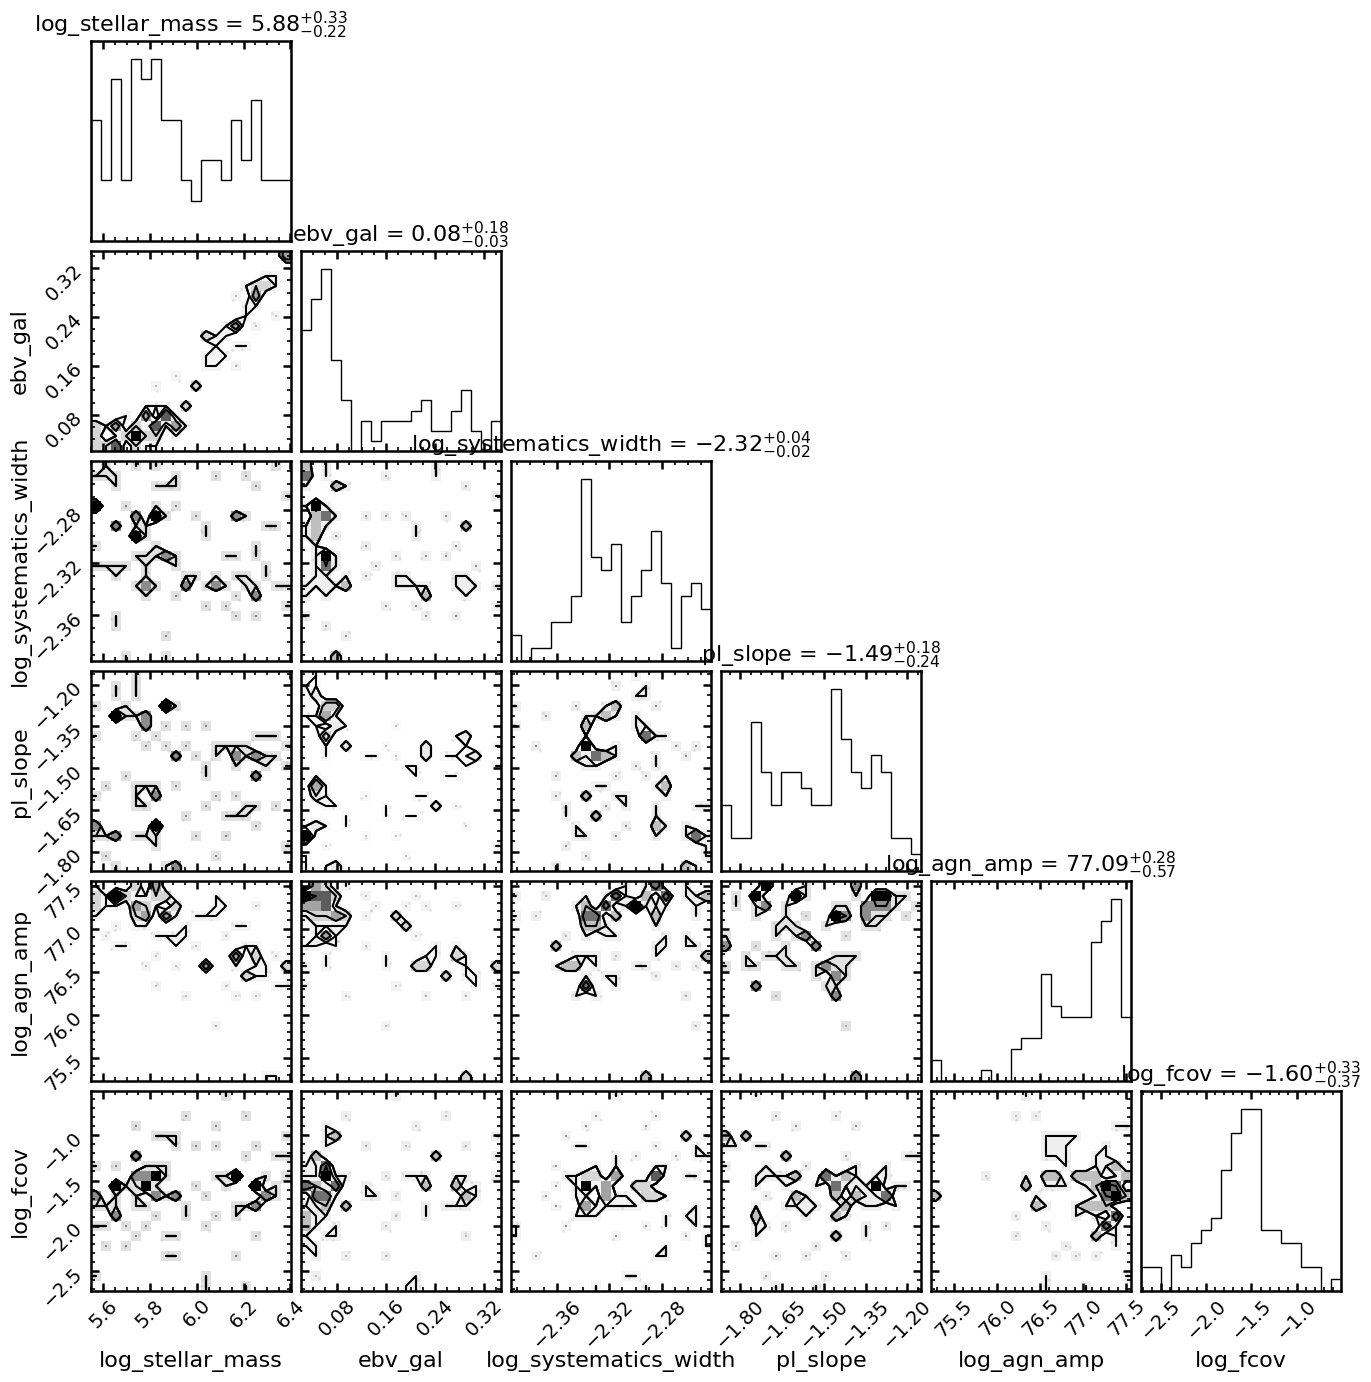

Parameters:
  log_stellar_mass: mean=5.92673, median=5.87868
  ebv_gal: mean=0.128434, median=0.0765188
  log_systematics_width: mean=-2.30923, median=-2.31648
  pl_slope: mean=-1.51765, median=-1.48964
  log_agn_amp: mean=76.957, median=77.0945
  log_fcov: mean=-1.61761, median=-1.60315

Covariance matrix:
[[ 5.78021392e-02  2.18911087e-02 -1.60839493e-03 -1.80816610e-03
  -7.28865879e-02  1.57381064e-02]
 [ 2.18911087e-02  9.42097995e-03 -7.52715540e-04 -5.53409774e-05
  -2.77608135e-02  5.39922654e-03]
 [-1.60839493e-03 -7.52715540e-04  1.22142892e-03 -1.88394849e-03
   1.01374396e-03  6.02162015e-04]
 [-1.80816610e-03 -5.53409774e-05 -1.88394849e-03  3.21978980e-02
   8.47894987e-03 -7.39442758e-03]
 [-7.28865879e-02 -2.77608135e-02  1.01374396e-03  8.47894987e-03
   2.04139860e-01 -2.39020385e-02]
 [ 1.57381064e-02  5.39922654e-03  6.02162015e-04 -7.39442758e-03
  -2.39020385e-02  1.66255820e-01]]

Covariance pairs:
  cov(log_stellar_mass, ebv_gal) = 0.0218911
  cov(log_stellar_ma

In [18]:
import corner
import numpy as np
import matplotlib.pyplot as plt

samples = jaxsedfit_fitter.samples

params = [
    "log_stellar_mass",
    "sfh_age_gyr",
    "sfh_tau_gyr",
    "ebv_gal",
    "log_systematics_width",
    "pl_slope",
    "log_uv_slope_delta",
    "log_agn_amp",
    "log_fcov",
    "log_hot_lam"

]
params = [p for p in params if p in samples]

chain = np.column_stack([
    np.asarray(samples[p]).reshape(-1)
    for p in params
])

corner.corner(chain, labels=params, show_titles=True)
plt.show()

means = np.mean(chain, axis=0)
medians = np.median(chain, axis=0)
cov = np.cov(chain, rowvar=False)

print("Parameters:")
for name, mean, median in zip(params, means, medians):
    print(f"  {name}: mean={mean:.6g}, median={median:.6g}")

print("\nCovariance matrix:")
print(cov)

print("\nCovariance pairs:")
for i, p1 in enumerate(params):
    for j in range(i + 1, len(params)):
        p2 = params[j]
        print(f"  cov({p1}, {p2}) = {cov[i, j]:.6g}")

In [19]:
for k in [
    "fracAGN_5100_fit",
    "log_agn_bol_luminosity_fit",
    "log_disk_luminosity_fit",
    "log_stellar_mass",
    "ebv_gal",
    "dust_alpha",
]:
    if k in samples:
        x = np.asarray(samples[k]).reshape(-1)
        print(k, np.nanpercentile(x, [16, 50, 84]))

fracAGN_5100_fit [0.13506068 0.35668047 0.54575964]
log_agn_bol_luminosity_fit [34.19897639 34.4483275  34.56815645]
log_disk_luminosity_fit [29.52479523 29.77414634 29.89397529]
log_stellar_mass [5.66054679 5.87868166 6.21034636]
ebv_gal [0.04195343 0.0765188  0.25766056]
dust_alpha [1.96263127 2.27038637 2.49432186]


## Write GRAHSP Inputs

This is the same input-table conversion used in Notebook 12. GRAHSP expects CIGALE-style filter column names in mJy, with `IRAC1` and `IRAC2` instead of the Chimera column names.

The cell is guarded by `RUN_GRAHSP`. If GRAHSP is disabled, the notebook defines the paths and filter mapping but does not write input files.


In [20]:
chimera_to_grahsp_filters = {
    "u_sdss": "u_sdss",
    "r_sdss": "r_sdss",
    "i_sdss": "i_sdss",
    "z_sdss": "z_sdss",
    "J_2mass": "J_2mass",
    "H_2mass": "H_2mass",
    "Ks_2mass": "Ks_2mass",
    "spitzer.irac.I1": "IRAC1",
    "spitzer.irac.I2": "IRAC2",
}

input_path = grahsp_output_dir / "chimera_object.ecsv"

if RUN_GRAHSP:
    table_data = {
        "id": [str(row["id"])],
        "redshift": [float(row["redshift"])],
        "redshift_err": [0.0],
    }
    for chimera_name, grahsp_name in chimera_to_grahsp_filters.items():
        flux = float(row[chimera_name])
        err = float(row[f"{chimera_name}_err"])
        table_data[grahsp_name] = [flux if np.isfinite(flux) else -9999.0]
        table_data[f"{grahsp_name}_err"] = [err if np.isfinite(err) and err > 0 else -9999.0]

    input_table = Table(table_data)
    input_table.write(input_path, format="ascii.ecsv", overwrite=True)
    print("Wrote", input_path)
else:
    input_table = None
    print("RUN_GRAHSP is False; skipping GRAHSP input-table write.")

input_table


RUN_GRAHSP is False; skipping GRAHSP input-table write.


## Build `pcigale.ini`

The GRAHSP configuration is copied from Notebook 12 so both notebooks use the same original-GRAHSP setup. This cell writes the file only when `RUN_GRAHSP=True`.


In [21]:
if RUN_GRAHSP:
    filters = list(chimera_to_grahsp_filters.values())
    column_list = []
    for name in filters:
        column_list.extend([name, f"{name}_err"])

    pcigale_ini = f"""
    data_file = {input_path}
    column_list = {', '.join(column_list)}
    creation_modules = sfh2exp, m2005, nebular, activate, activatelines, activategtorus, activatepl, activatebol, biattenuation, galdale2014, redshifting
    analysis_method = pdf_analysis
    cores = 1
    cosmology = concordance

    [statistics]
      exponent = 2
      systematics_width = 0.03
      variability_uncertainty = true
      attenuation_model_uncertainty = false
      Ly_break_uncertainty = false

    [sed_creation_modules]
      [[sfh2exp]]
        tau_main = 500, 1500, 4000, 8000
        tau_burst = 50
        f_burst = 0.0, 0.01, 0.1
        age = 500, 1000, 3000, 6000, 9000, 12000
        burst_age = 20, 100
        sfr_0 = 1
        normalise = True

      [[m2005]]
        imf = 1
        metallicity = 0.02
        separation_age = 10

      [[nebular]]
        logU = -2.0
        zgas = 0.02
        ne = 100
        f_esc = 0.0
        f_dust = 0.0
        lines_width = 300
        emission = True

      [[activate]]
        fracAGN = -1

      [[activatelines]]
        AFeII = 5
        AGNtype = 1
        linewidth = 3000
        Alines = 1
        ABC = 0

      [[activategtorus]]
        fcov = 0.05, 0.2, 0.5
        Si = 0
        COOLlam = 17
        COOLwidth = 0.45
        HOTlam = 2.0
        HOTwidth = 0.5
        HOTfcov = 0.0, 0.5
        SiRatio = 0.29
        SiEmlam = 9841
        SiAbslam = 14224
        SiEmWidth = 1025.3
        SiAbsWidth = 1163.5

      [[activatepl]]
        plslope = -1.8
        plbendloc = 90
        plbendwidth = 0.5
        uvslope = 0
        cutoff = 10000

      [[activatebol]]

      [[biattenuation]]
        OPT_index = -1.2
        NIR_index = -3.0
        norm = 1.2
        lam_break = 1100
        E(B-V) = 0.001, 0.01, 0.1
        E(B-V)-AGN = 0.001, 0.03, 0.3, 1.0
        filters =

      [[galdale2014]]
        alpha = 2.0
        lam_max = -1

      [[redshifting]]
        redshift =

    [analysis_configuration]
      analysed_variables = stellar.mass_total, stellar.mass_alive, sfh.sfr, sfh.sfr100Myrs, agn.lumBolBBB, agn.lumBolTOR, agn.fracAGNDale
      save_best_sed = False
      save_chi2 = False
      save_pdf = False
      lim_flag = False
      mock_flag = False
    """

    config_path = grahsp_output_dir / "pcigale.ini"
    config_path.write_text(textwrap.dedent(pcigale_ini).strip() + "\n")
    print("Wrote", config_path)
    print(config_path.read_text()[:1200])
else:
    config_path = grahsp_output_dir / "pcigale.ini"
    print("RUN_GRAHSP is False; skipping pcigale.ini write.")


RUN_GRAHSP is False; skipping pcigale.ini write.


## Run GRAHSP

This calls the original GRAHSP nested sampler only when `RUN_GRAHSP=True`. `MAKE_GRAHSP_PLOTS=True` is required for the `sed_mJy.csv.gz` product used in the side-by-side comparison.


In [22]:
if RUN_GRAHSP:
    if repo_root is None or sampler_script is None or not sampler_script.is_file():
        raise RuntimeError(
            "RUN_GRAHSP=True requires running from a full GRAHSP checkout with sampler/dualsampler.py. "
            "Set RUN_GRAHSP=False for a JAXSEDFit-only run."
        )
    if cigale_root is None or not cigale_root.exists():
        raise RuntimeError("RUN_GRAHSP=True requires the GRAHSP cigale directory.")

    cmd = [
        sys.executable,
        str(sampler_script),
        "analyse",
        "--cores", "1",
        "--num-live-points", str(GRAHSP_NUM_LIVE_POINTS),
        "--num-posterior-samples", str(GRAHSP_NUM_POSTERIOR_SAMPLES),
        "--mass-max", "13",
    ]
    if MAKE_GRAHSP_PLOTS:
        cmd.append("--plot")

    env = os.environ.copy()
    env["PYTHONPATH"] = os.pathsep.join([str(cigale_root), str(src_root), env.get("PYTHONPATH", "")])
    env["OMP_NUM_THREADS"] = "1"
    env["HDF5_USE_FILE_LOCKING"] = "FALSE"
    env["MPLCONFIGDIR"] = str(grahsp_output_dir / "mplconfig")
    env["CACHE_MAX"] = "5000"
    (grahsp_output_dir / "mplconfig").mkdir(exist_ok=True)

    print("Working directory:", grahsp_output_dir)
    print("Command:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=grahsp_output_dir, env=env, text=True, capture_output=True)
    print(completed.stdout[-6000:])
    if completed.returncode != 0:
        print(completed.stderr[-6000:])
        raise RuntimeError(f"GRAHSP failed with return code {completed.returncode}")
else:
    print("RUN_GRAHSP is False; skipping GRAHSP execution.")


RUN_GRAHSP is False; skipping GRAHSP execution.


## Read GRAHSP Summary And SED Products

The mass summary is optional for the SED comparison, but it is useful context. The SED CSV is written only when GRAHSP is run with `--plot`.

If `RUN_GRAHSP=False`, this cell will read existing GRAHSP products when `USE_EXISTING_GRAHSP_OUTPUTS=True`; otherwise it records that GRAHSP products are unavailable and downstream plots switch to JAXSEDFit-only views.


In [23]:
summary_path = grahsp_output_dir / "chimera_object.ecsv_analysis_results.txt"
grahsp_available = False
grahsp_summary = None
grahsp_sed = None
grahsp_recovered_logm = np.nan
grahsp_logm_lo = np.nan
grahsp_logm_hi = np.nan

should_read_grahsp = RUN_GRAHSP or USE_EXISTING_GRAHSP_OUTPUTS
if should_read_grahsp and summary_path.is_file():
    grahsp_summary = Table.read(summary_path, format="ascii.commented_header", delimiter="	")
    grahsp_recovered_logm = float(grahsp_summary["log_stellar_mass_med"][0])
    grahsp_logm_lo = float(grahsp_summary["log_stellar_mass_lo"][0])
    grahsp_logm_hi = float(grahsp_summary["log_stellar_mass_hi"][0])

    plot_dirs = sorted(grahsp_output_dir.glob("grahsp_*/plots"))
    print("Plot directories:", plot_dirs)
    if plot_dirs:
        grahsp_sed_path = plot_dirs[0] / "sed_mJy.csv.gz"
        if grahsp_sed_path.is_file():
            grahsp_sed = Table.read(grahsp_sed_path, format="ascii.csv")
            grahsp_available = True
        else:
            print("Missing GRAHSP SED CSV:", grahsp_sed_path)
    else:
        print("No GRAHSP plot directory found. Re-run with RUN_GRAHSP=True and MAKE_GRAHSP_PLOTS=True.")
elif should_read_grahsp:
    print("No existing GRAHSP summary found:", summary_path)
else:
    print("Skipping GRAHSP product read because RUN_GRAHSP and USE_EXISTING_GRAHSP_OUTPUTS are both False.")

print("truth log stellar mass:", truth_logm)
if grahsp_available:
    print("GRAHSP recovered log stellar mass:", grahsp_recovered_logm)
    print("GRAHSP 95.45% interval:", (grahsp_logm_lo, grahsp_logm_hi))
    print("GRAHSP residual:", grahsp_recovered_logm - truth_logm)
    print("GRAHSP SED columns:", grahsp_sed.colnames)
else:
    print("GRAHSP products unavailable; downstream comparison cells will skip GRAHSP overlays.")


No existing GRAHSP summary found: /Users/colinburke/research/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/075217.84+193542.2_315709_0.0001/grahsp/chimera_object.ecsv_analysis_results.txt
truth log stellar mass: 9.08123
GRAHSP products unavailable; downstream comparison cells will skip GRAHSP overlays.


## Side-By-Side SED Comparison

Both panels use observed-frame wavelength and mJy. The JAXSEDFit panel is drawn from the posterior predictive spectrum; the GRAHSP panel is drawn from `sed_mJy.csv.gz`.


5.878681662341199
Wrote /Users/colinburke/research/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/075217.84+193542.2_315709_0.0001/jaxsedfit_sed.png
GRAHSP products unavailable; wrote the JAXSEDFit-only SED panel.


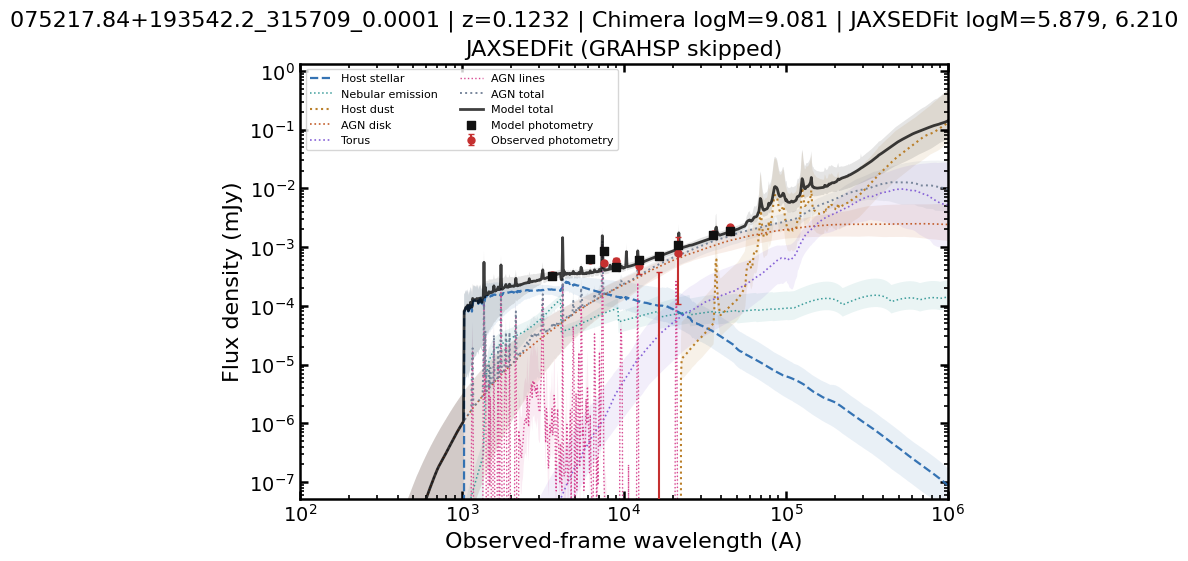

In [24]:
from jaxsedfit.plotting import _median_site_sum, _percentile_site_sum


def _positive_component(y):
    y = np.asarray(y, dtype=float)
    return np.isfinite(y) & (y > 0.0)


def plot_jaxsedfit_panel(ax, fitter, pred):
    obs_wave_a = _median_site(pred, "obs_wave")
    phot_wave_a = np.asarray([flt.effective_wavelength for flt in fitter.context.filters], dtype=float)
    obs_flux = np.asarray(fitter.config.photometry.fluxes, dtype=float)
    obs_err = np.asarray(fitter.config.photometry.errors, dtype=float)
    model_flux = _median_site(pred, "pred_fluxes")

    labels_seen = set()
    all_y = [obs_flux, model_flux]

    for keys, label, color, lw in _COMPONENT_STYLE:
        key_list = keys if isinstance(keys, (list, tuple, set)) else [keys]
        key_tuple = tuple(key_list)

        if not any(key in pred for key in key_tuple):
            continue

        component = _to_display_flux_density(obs_wave_a, _median_site_sum(pred, key_tuple))
        if not np.any(_positive_component(component)):
            continue

        lo = _to_display_flux_density(obs_wave_a, _percentile_site_sum(pred, key_tuple, 16.0))
        hi = _to_display_flux_density(obs_wave_a, _percentile_site_sum(pred, key_tuple, 84.0))

        all_y.extend([component, lo, hi])
        plot_label = label if label not in labels_seen else "_nolegend_"
        labels_seen.add(label)

        if np.any(_positive_component(lo) & _positive_component(hi)):
            ax.fill_between(
                obs_wave_a,
                np.clip(np.minimum(lo, hi), 1e-300, None),
                np.clip(np.maximum(lo, hi), 1e-300, None),
                color=color,
                alpha=0.10,
                linewidth=0.0,
            )

        ls = "-" if "total_obs_sed" in key_tuple else ("--" if "host_obs_sed" in key_tuple else ":")
        alpha = 0.75 if "total_obs_sed" in key_tuple else 0.95
        ax.plot(obs_wave_a, component, color=color, lw=lw, ls=ls, alpha=alpha, label=plot_label)

    ax.errorbar(phot_wave_a, obs_flux, yerr=obs_err, fmt="o", color="#c53030", ms=5, capsize=2, label="Observed photometry", zorder=5)
    ax.scatter(phot_wave_a, model_flux, color="#111111", marker="s", s=28, label="Model photometry", zorder=6)
    ax.set_title("JAXSEDFit")
    return all_y


def plot_grahsp_panel(ax, sed_table, row):
    wave_um = np.asarray(sed_table["wavelength"], dtype=float)
    wave_a = wave_um * 1.0e4
    all_y = []

    column_styles = [
        ("total", "Model total", "#000000", 2.0, "-"),
        ("Stellar (attenuated)", "Host stellar", "#2b6cb0", 1.6, "--"),
        ("Nebular emission", "Nebular emission", "#319795", 1.1, ":"),
        ("Dust", "Host dust", "#b7791f", 1.5, ":"),
        ("AGN disk", "AGN disk", "#c05621", 1.2, ":"),
        ("AGN torus", "Torus", "#805ad5", 1.2, ":"),
        ("FeII", "Fe II", "#2f855a", 1.0, ":"),
        ("AGN lines", "AGN lines", "#d53f8c", 1.0, ":"),
        ("Balmer continuum", "Balmer cont.", "#dd6b20", 1.0, ":"),
    ]

    for col, label, color, lw, ls in column_styles:
        if col not in sed_table.colnames:
            continue

        y = np.asarray(sed_table[col], dtype=float)
        if not np.any(_positive_component(y)):
            continue

        all_y.append(y)
        ax.plot(wave_a, y, color=color, lw=lw, ls=ls, alpha=0.95, label=label)

    phot_wave_a = np.asarray([flt.effective_wavelength for flt in jaxsedfit_fitter.context.filters], dtype=float)
    obs_flux = np.asarray([float(row[name]) for name in chimera_to_grahsp_filters], dtype=float)
    obs_err = np.asarray([float(row[f"{name}_err"]) for name in chimera_to_grahsp_filters], dtype=float)

    all_y.extend([obs_flux, obs_err])

    ax.errorbar(
        phot_wave_a,
        obs_flux,
        yerr=obs_err,
        fmt="o",
        color="#c53030",
        ms=5,
        capsize=2,
        label="Observed photometry",
        zorder=5,
    )
    ax.set_title("GRAHSP")
    return all_y


ncols = 2 if grahsp_available else 1
fig, axes = plt.subplots(
    1,
    ncols,
    figsize=(14, 5.5) if grahsp_available else (7.5, 5.5),
    sharex=True,
    sharey=True,
    layout="constrained",
)
axes = np.atleast_1d(axes)

y_parts = []
y_parts.extend(plot_jaxsedfit_panel(axes[0], jaxsedfit_fitter, jaxsedfit_pred))
if grahsp_available:
    y_parts.extend(plot_grahsp_panel(axes[1], grahsp_sed, row))
else:
    axes[0].set_title("JAXSEDFit (GRAHSP skipped)")

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Observed-frame wavelength (A)")
    ax.legend(fontsize=8, ncol=2, loc="best")

axes[0].set_ylabel("Flux density (mJy)")

finite_y = np.concatenate([np.ravel(np.asarray(y, dtype=float)) for y in y_parts])
finite_y = finite_y[np.isfinite(finite_y) & (finite_y > 0.0)]

if finite_y.size:
    ymax = float(np.nanmax(finite_y))
    ymin = (
        float(np.nanmin(finite_y[finite_y >= ymax * 1e-7]))
        if np.any(finite_y >= ymax * 1e-7)
        else float(np.nanmin(finite_y))
    )

    for ax in axes:
        ax.set_ylim(ymin * 0.7, ymax * 1.8)
        ax.set_xlim(1e2, 1e6)
print(jaxsedfit_recovered_logm)
fig.suptitle(f"{row['id']} | z={float(row['redshift']):.4f} | Chimera logM={truth_logm:.3f} | JAXSEDFit logM={jaxsedfit_recovered_logm:.3f}, {jaxsedfit_logm84:.3f}")
comparison_path = base_output_dir / ("grahsp_vs_jaxsedfit_sed.png" if grahsp_available else "jaxsedfit_sed.png")
fig.savefig(comparison_path, dpi=180)

print("Wrote", comparison_path)
if not grahsp_available:
    print("GRAHSP products unavailable; wrote the JAXSEDFit-only SED panel.")
plt.show()


## Normalized Host Stellar Shape Diagnostic

This compares the host stellar continuum shapes after normalizing each model at rest-frame 5100 Angstrom. GRAHSPJ uses `host_rest_sed` directly. GRAHSP is read from `Stellar (attenuated)` in `sed_mJy.csv.gz`, converted from observed-frame `F_nu` to an `F_lambda`-proportional shape, shifted to rest-frame wavelength, and normalized at the same wavelength.


In [25]:
if not grahsp_available:
    print("Skipping host-shape comparison because GRAHSP products are unavailable.")
else:
    def _positive_norm_curve(wave, y, norm_wave=5100.0):
        wave = np.asarray(wave, dtype=float)
        y = np.asarray(y, dtype=float)
        order = np.argsort(wave)
        wave = wave[order]
        y = y[order]
        finite = np.isfinite(wave) & np.isfinite(y) & (wave > 0.0) & (y > 0.0)
        if finite.sum() < 3:
            return wave, np.full_like(wave, np.nan), np.nan
        norm = np.interp(norm_wave, wave[finite], y[finite], left=np.nan, right=np.nan)
        if not np.isfinite(norm) or norm <= 0.0:
            nearest = np.nanargmin(np.abs(wave[finite] - norm_wave))
            norm = y[finite][nearest]
        return wave, y / norm, norm


    def _grahsp_mjy_to_flambda_shape(wave_obs_a, flux_mjy):
        # Constants cancel after normalization; this preserves the F_lambda shape.
        wave_obs_a = np.asarray(wave_obs_a, dtype=float)
        flux_mjy = np.asarray(flux_mjy, dtype=float)
        return flux_mjy / np.maximum(wave_obs_a, 1.0e-30) ** 2


    norm_wave_a = 5100.0
    z_object = float(row["redshift"])

    # JAXSEDFit: native rest-frame L_lambda host stellar component.
    jaxsedfit_rest_wave = np.nanmedian(np.asarray(jaxsedfit_pred["rest_wave"], dtype=float), axis=0)
    jaxsedfit_host_rest = np.nanmedian(np.asarray(jaxsedfit_pred["host_rest_sed"], dtype=float), axis=0)
    jaxsedfit_host_lo = np.nanpercentile(np.asarray(jaxsedfit_pred["host_rest_sed"], dtype=float), 16.0, axis=0)
    jaxsedfit_host_hi = np.nanpercentile(np.asarray(jaxsedfit_pred["host_rest_sed"], dtype=float), 84.0, axis=0)

    jaxsedfit_wave, jaxsedfit_host_normed, jaxsedfit_norm = _positive_norm_curve(jaxsedfit_rest_wave, jaxsedfit_host_rest, norm_wave_a)
    _, jaxsedfit_host_lo_normed, _ = _positive_norm_curve(jaxsedfit_rest_wave, jaxsedfit_host_lo, norm_wave_a)
    _, jaxsedfit_host_hi_normed, _ = _positive_norm_curve(jaxsedfit_rest_wave, jaxsedfit_host_hi, norm_wave_a)

    # GRAHSP: sed_mJy.csv.gz wavelengths are observed-frame; convert F_nu-like mJy to F_lambda shape.
    grahsp_wave_obs_a = np.asarray(grahsp_sed["wavelength"], dtype=float) * 1.0e4
    grahsp_wave_rest_a = grahsp_wave_obs_a / (1.0 + z_object)
    grahsp_stellar_flambda_shape = _grahsp_mjy_to_flambda_shape(
        grahsp_wave_obs_a,
        np.asarray(grahsp_sed["Stellar (attenuated)"], dtype=float),
    )
    grahsp_wave, grahsp_host_normed, grahsp_norm = _positive_norm_curve(
        grahsp_wave_rest_a,
        grahsp_stellar_flambda_shape,
        norm_wave_a,
    )

    fig, ax = plt.subplots(figsize=(7.6, 5.2), constrained_layout=True)
    ax.plot(
        jaxsedfit_wave,
        jaxsedfit_host_normed,
        color="#c53030",
        lw=2.0,
        label="JAXSEDFit host_rest_sed / 5100 A",
    )
    if np.any(np.isfinite(jaxsedfit_host_lo_normed) & np.isfinite(jaxsedfit_host_hi_normed)):
        ax.fill_between(
            jaxsedfit_wave,
            np.clip(np.minimum(jaxsedfit_host_lo_normed, jaxsedfit_host_hi_normed), 1.0e-12, None),
            np.clip(np.maximum(jaxsedfit_host_lo_normed, jaxsedfit_host_hi_normed), 1.0e-12, None),
            color="#c53030",
            alpha=0.12,
            linewidth=0.0,
        )
    ax.plot(
        grahsp_wave,
        grahsp_host_normed,
        color="#2b6cb0",
        lw=2.0,
        ls="--",
        label="GRAHSP Stellar (attenuated) / 5100 A",
    )
    ax.axvline(norm_wave_a, color="0.25", lw=1.0, ls=":")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(7.0e2, 2.0e5)
    ax.set_ylim(1.0e-4, 1.0e2)
    ax.set_xlabel("Rest-frame wavelength (A)")
    ax.set_ylabel("Host stellar shape normalized at 5100 A")
    ax.set_title("Normalized Host Stellar Rest-Frame Shape")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=9)

    host_shape_path = base_output_dir / "host_stellar_rest_shape_comparison.png"
    fig.savefig(host_shape_path, dpi=180)
    print("JAXSEDFit normalization at 5100 A:", jaxsedfit_norm)
    print("GRAHSP F_lambda-shape normalization at 5100 A:", grahsp_norm)
    print("Wrote", host_shape_path)
    plt.show()


Skipping host-shape comparison because GRAHSP products are unavailable.


## Normalized AGN Disk Shape Diagnostic

This repeats the 5100 Angstrom rest-frame shape comparison for the AGN disk continuum. GRAHSPJ uses `disk_rest_sed` directly. GRAHSP is read from `AGN disk` in `sed_mJy.csv.gz`, converted from observed-frame `F_nu` to an `F_lambda`-proportional shape, shifted to rest-frame wavelength, and normalized at 5100 Angstrom.


In [26]:
if not grahsp_available:
    print("Skipping AGN disk-shape comparison because GRAHSP products are unavailable.")
else:
    # Reuse _positive_norm_curve and _grahsp_mjy_to_flambda_shape from the host-shape diagnostic if present.
    try:
        _positive_norm_curve
        _grahsp_mjy_to_flambda_shape
    except NameError:
        def _positive_norm_curve(wave, y, norm_wave=5100.0):
            wave = np.asarray(wave, dtype=float)
            y = np.asarray(y, dtype=float)
            order = np.argsort(wave)
            wave = wave[order]
            y = y[order]
            finite = np.isfinite(wave) & np.isfinite(y) & (wave > 0.0) & (y > 0.0)
            if finite.sum() < 3:
                return wave, np.full_like(wave, np.nan), np.nan
            norm = np.interp(norm_wave, wave[finite], y[finite], left=np.nan, right=np.nan)
            if not np.isfinite(norm) or norm <= 0.0:
                nearest = np.nanargmin(np.abs(wave[finite] - norm_wave))
                norm = y[finite][nearest]
            return wave, y / norm, norm


        def _grahsp_mjy_to_flambda_shape(wave_obs_a, flux_mjy):
            # Constants cancel after normalization; this preserves the F_lambda shape.
            wave_obs_a = np.asarray(wave_obs_a, dtype=float)
            flux_mjy = np.asarray(flux_mjy, dtype=float)
            return flux_mjy / np.maximum(wave_obs_a, 1.0e-30) ** 2


    norm_wave_a = 5100.0
    z_object = float(row["redshift"])

    # JAXSEDFit: native rest-frame L_lambda AGN disk component.
    jaxsedfit_rest_wave = np.nanmedian(np.asarray(jaxsedfit_pred["rest_wave"], dtype=float), axis=0)
    jaxsedfit_disk_rest = np.nanmedian(np.asarray(jaxsedfit_pred["disk_rest_sed"], dtype=float), axis=0)
    jaxsedfit_disk_lo = np.nanpercentile(np.asarray(jaxsedfit_pred["disk_rest_sed"], dtype=float), 16.0, axis=0)
    jaxsedfit_disk_hi = np.nanpercentile(np.asarray(jaxsedfit_pred["disk_rest_sed"], dtype=float), 84.0, axis=0)

    jaxsedfit_wave, jaxsedfit_disk_normed, jaxsedfit_disk_norm = _positive_norm_curve(jaxsedfit_rest_wave, jaxsedfit_disk_rest, norm_wave_a)
    _, jaxsedfit_disk_lo_normed, _ = _positive_norm_curve(jaxsedfit_rest_wave, jaxsedfit_disk_lo, norm_wave_a)
    _, jaxsedfit_disk_hi_normed, _ = _positive_norm_curve(jaxsedfit_rest_wave, jaxsedfit_disk_hi, norm_wave_a)

    # GRAHSP: sed_mJy.csv.gz wavelengths are observed-frame; convert F_nu-like mJy to F_lambda shape.
    grahsp_wave_obs_a = np.asarray(grahsp_sed["wavelength"], dtype=float) * 1.0e4
    grahsp_wave_rest_a = grahsp_wave_obs_a / (1.0 + z_object)
    grahsp_disk_flambda_shape = _grahsp_mjy_to_flambda_shape(
        grahsp_wave_obs_a,
        np.asarray(grahsp_sed["AGN disk"], dtype=float),
    )
    grahsp_wave, grahsp_disk_normed, grahsp_disk_norm = _positive_norm_curve(
        grahsp_wave_rest_a,
        grahsp_disk_flambda_shape,
        norm_wave_a,
    )

    fig, ax = plt.subplots(figsize=(7.6, 5.2), constrained_layout=True)
    ax.plot(
        jaxsedfit_wave,
        jaxsedfit_disk_normed,
        color="#c53030",
        lw=2.0,
        label="JAXSEDFit disk_rest_sed / 5100 A",
    )
    if np.any(np.isfinite(jaxsedfit_disk_lo_normed) & np.isfinite(jaxsedfit_disk_hi_normed)):
        ax.fill_between(
            jaxsedfit_wave,
            np.clip(np.minimum(jaxsedfit_disk_lo_normed, jaxsedfit_disk_hi_normed), 1.0e-12, None),
            np.clip(np.maximum(jaxsedfit_disk_lo_normed, jaxsedfit_disk_hi_normed), 1.0e-12, None),
            color="#c53030",
            alpha=0.12,
            linewidth=0.0,
        )
    ax.plot(
        grahsp_wave,
        grahsp_disk_normed,
        color="#2b6cb0",
        lw=2.0,
        ls="--",
        label="GRAHSP AGN disk / 5100 A",
    )
    ax.axvline(norm_wave_a, color="0.25", lw=1.0, ls=":")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(7.0e2, 2.0e5)
    ax.set_ylim(1.0e-5, 1.0e3)
    ax.set_xlabel("Rest-frame wavelength (A)")
    ax.set_ylabel("AGN disk shape normalized at 5100 A")
    ax.set_title("Normalized AGN Disk Rest-Frame Shape")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=9)

    agn_disk_shape_path = base_output_dir / "agn_disk_rest_shape_comparison.png"
    fig.savefig(agn_disk_shape_path, dpi=180)
    print("JAXSEDFit disk normalization at 5100 A:", jaxsedfit_disk_norm)
    print("GRAHSP disk F_lambda-shape normalization at 5100 A:", grahsp_disk_norm)
    print("Wrote", agn_disk_shape_path)
    plt.show()


Skipping AGN disk-shape comparison because GRAHSP products are unavailable.


## Mass Context

This last panel is not the main comparison, but it helps interpret whether a SED difference is accompanied by a stellar-mass difference.


In [27]:
jaxsedfit_recovered_logm

np.float64(5.878681662341199)

GRAHSP products unavailable; mass context shows JAXSEDFit only.


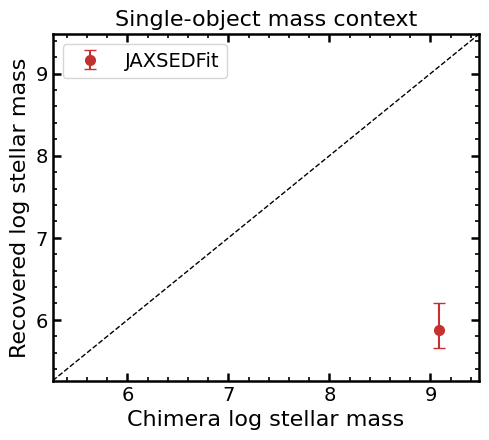

In [28]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.errorbar(
    [truth_logm],
    [jaxsedfit_recovered_logm],
    yerr=[[jaxsedfit_recovered_logm - jaxsedfit_logm16], [jaxsedfit_logm84 - jaxsedfit_recovered_logm]],
    fmt="o",
    color="#c53030",
    capsize=4,
    ms=7,
    label="JAXSEDFit",
)

mass_values = [truth_logm, jaxsedfit_logm16, jaxsedfit_logm84]
if grahsp_available:
    ax.errorbar(
        [truth_logm],
        [grahsp_recovered_logm],
        yerr=[[grahsp_recovered_logm - grahsp_logm_lo], [grahsp_logm_hi - grahsp_recovered_logm]],
        fmt="s",
        color="#2b6cb0",
        capsize=4,
        ms=7,
        label="GRAHSP",
    )
    mass_values.extend([grahsp_logm_lo, grahsp_logm_hi])
else:
    print("GRAHSP products unavailable; mass context shows JAXSEDFit only.")

lims = [min(mass_values) - 0.4, max(mass_values) + 0.4]
ax.plot(lims, lims, color="black", ls="--", lw=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Chimera log stellar mass")
ax.set_ylabel("Recovered log stellar mass")
ax.legend()
ax.set_title("Single-object mass context")
plt.show()
